In [3]:
!pip install scipy  
from scipy import stats  



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


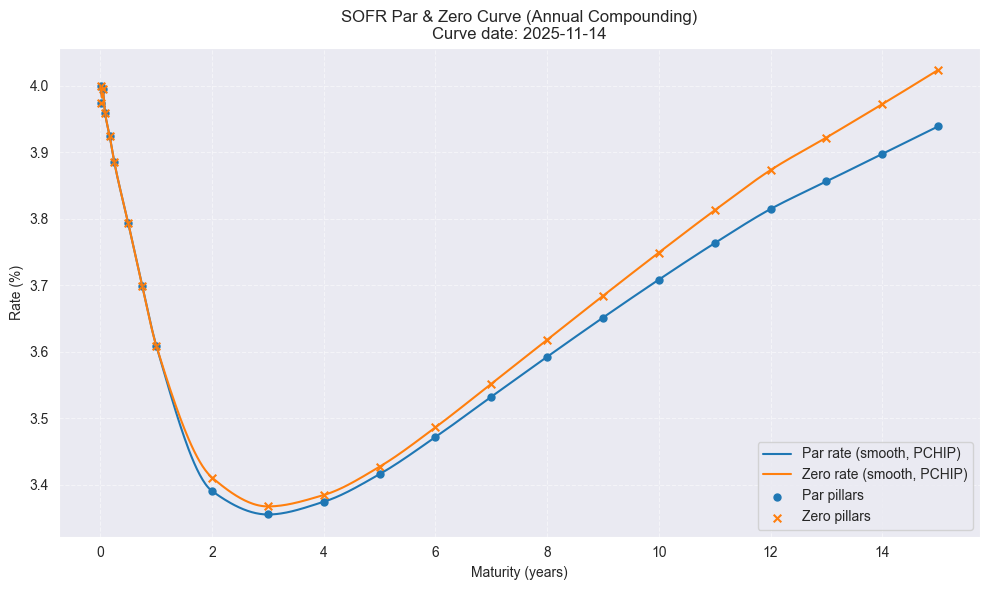

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy.interpolate import PchipInterpolator

# ==========================
# 1. read filled data
# ==========================
FILE_PATH = r"./SOFR_SWAP.wide.filled.xls"

df_raw = pd.read_csv(FILE_PATH, sep="\t")

date_col = "Date"
df_raw[date_col] = pd.to_datetime(df_raw[date_col])
df = df_raw.set_index(date_col).sort_index()

# ==========================
# 2. column -> tenors(in year)
# ==========================
def tenor_to_years(col_name: str) -> float:
    s = str(col_name).strip().upper()
    if s == "ON":
        # Overnight = 1/360
        return 1.0 / 360.0

    # similar with "1W", "2W", "1M", "3M", "6M", "1Y", "10Y"
    m = re.fullmatch(r"(\d+)([WMY])", s)
    if m:
        n = float(m.group(1))
        unit = m.group(2)
        if unit == "W":
            return n * 7.0 / 360.0
        elif unit == "M":
            return n / 12.0
        elif unit == "Y":
            return n

    raise ValueError(f"cannot convert: {col_name}")

par_cols = list(df.columns)                # all non-date colomns
pillars_years = np.array([tenor_to_years(c) for c in par_cols], dtype=float)


# ==========================
# 3. Bootstrapping
#    - T ≤ 1Y：zero = par
#    - T > 1Y: Annual Fixed vs Compounded SOFR bootstrapping
# ==========================
def bootstrap_zero_annual(maturities, par_rates):
    maturities = np.asarray(maturities, dtype=float)
    par_rates = np.asarray(par_rates, dtype=float)

    order = np.argsort(maturities)
    T = maturities[order]
    S = par_rates[order]

    n = len(T)
    dfs = np.zeros(n)
    zero_annual = np.zeros(n)
    alpha = np.diff(T, prepend=0.0)   # 时间间隔

    for i in range(n):
        if T[i] <= 1.0:
            # 1 year and below：zero rate = par/swap rate
            dfs[i] = 1.0 / (1.0 + S[i] * T[i])
            zero_annual[i] = S[i]
        else:
            # >1Y：annual SOFR swap bootstrapping
            known_annuity = np.sum(alpha[:i] * dfs[:i])     # knwon annuity
            dfs[i] = (1.0 - S[i] * known_annuity) / (1.0 + S[i] * alpha[i])
            zero_annual[i] = dfs[i] ** (-1.0 / T[i]) - 1.0

    return T, S, dfs, zero_annual


# ==========================
# 4. bootstrapping example
# ==========================
curve_date = df.index[-1]
par_row = df.loc[curve_date, :].astype(float).values

T_pillars = pillars_years.copy()
mask = (~np.isnan(par_row)) & (T_pillars > 0)
T_pillars = T_pillars[mask]
par_values = par_row[mask]

T_used, par_used, dfs, zero_ann = bootstrap_zero_annual(T_pillars, par_values)

# ==========================
# 5. PCHIP used for smoothing
# ==========================
T_full = np.linspace(T_used[0], T_used[-1], 600)

par_spline = PchipInterpolator(T_used, par_used)
zero_spline = PchipInterpolator(T_used, zero_ann)

par_full = par_spline(T_full)
zero_full = zero_spline(T_full)

# convert it into %
par_pillars_pct = par_used * 100.0
zero_pillars_pct = zero_ann * 100.0
par_full_pct = par_full * 100.0
zero_full_pct = zero_full * 100.0

# ==========================
# 6. plot
# ==========================
plt.figure(figsize=(10, 6))

plt.plot(T_full, par_full_pct, label="Par rate (smooth, PCHIP)")
plt.plot(T_full, zero_full_pct, label="Zero rate (smooth, PCHIP)")

plt.scatter(T_used, par_pillars_pct, s=25, marker="o", label="Par pillars")
plt.scatter(T_used, zero_pillars_pct, s=30, marker="x", label="Zero pillars")

plt.xlabel("Maturity (years)")
plt.ylabel("Rate (%)")
plt.title(f"SOFR Par & Zero Curve (Annual Compounding)\nCurve date: {curve_date.date()}")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
# plt.show()
# plt.show()

# ==========================
# 7. export CSV
# ==========================
#smooth_df = pd.DataFrame({
#    "curve_date": [curve_date.date()] * len(T_full),
#    "T_years": T_full,
#    "Par_smooth_annual": par_full,
#    "Zero_smooth_annual": zero_full,
#})
#smooth_df.to_csv("SOFR_par_zero_curve_smooth_annual.csv", index=False)

#pillars_df = pd.DataFrame({
#    "curve_date": [curve_date.date()] * len(T_used),
#    "T_years": T_used,
#    "Par_pillar": par_used,
#    "Zero_pillar_annual": zero_ann,
#})
#pillars_df.to_csv("SOFR_par_zero_curve_pillars_annual.csv", index=False)


In [5]:
import pandas as pd
import numpy as np
import re
from scipy.interpolate import PchipInterpolator

# -------- Settings --------
FILE_PATH = r"./SOFR_SWAP.wide.filled.xls"
OUTPUT_EXCEL = r"./zero_curve_14to25.xlsx"

# Range（exceeding part will be cut）
START_DATE = "2014-01-01"
END_DATE   = "2025-12-31"


In [6]:
df_raw = pd.read_csv(FILE_PATH, sep="\t")

# dealing with date
date_col = "Date"
df_raw[date_col] = pd.to_datetime(df_raw[date_col])
df_raw = df_raw.set_index(date_col).sort_index()

df = df_raw.loc[START_DATE:END_DATE].copy()

par_cols = list(df.columns)

def tenor_to_years(col_name: str) -> float:
    s = str(col_name).strip().upper()
    if s == "ON":

        return 1.0 / 360.0

    m = re.fullmatch(r"(\d+)([WMY])", s)
    if m:
        n = float(m.group(1))
        unit = m.group(2)
        if unit == "W":
            return n * 7.0 / 360.0
        elif unit == "M":
            return n / 12.0
        elif unit == "Y":
            return n

    raise ValueError(f"cannot convert: {col_name}")

pillars_years = np.array([tenor_to_years(c) for c in par_cols], dtype=float)


In [7]:
def bootstrap_zero_annual(maturities, par_rates):
    maturities = np.asarray(maturities, dtype=float)
    par_rates = np.asarray(par_rates, dtype=float)

    order = np.argsort(maturities)
    T = maturities[order]
    S = par_rates[order]

    n = len(T)
    dfs = np.zeros(n)
    zero_annual = np.zeros(n)
    alpha = np.diff(T, prepend=0.0)   # time interval

    for i in range(n):
        if T[i] <= 1.0:
            dfs[i] = 1.0 / (1.0 + S[i] * T[i])
            zero_annual[i] = S[i]
        else:
            known_annuity = np.sum(alpha[:i] * dfs[:i])
            dfs[i] = (1.0 - S[i] * known_annuity) / (1.0 + S[i] * alpha[i])
            zero_annual[i] = dfs[i] ** (-1.0 / T[i]) - 1.0

    return T, zero_annual


In [8]:
def bootstrap_row_to_zero(row):
    """
    bootstrapping all the dates
    """
    par_vals = row.values.astype(float)

    mask = (~np.isnan(par_vals)) & (pillars_years > 0)
    if mask.sum() == 0:
        return pd.Series({col: np.nan for col in par_cols})

    T_use = pillars_years[mask]
    S_use = par_vals[mask]
    cols_use = np.array(par_cols)[mask]

    # convert it to zero rates
    T_boot, z_boot = bootstrap_zero_annual(T_use, S_use)

    T_to_col = dict(zip(T_use, cols_use))

    result_dict = {col: np.nan for col in par_cols}
    for T_i, z_i in zip(T_boot, z_boot):
        col_name = T_to_col[T_i]
        result_dict[col_name] = z_i

    return pd.Series(result_dict)

from tqdm import tqdm
tqdm.pandas()
# bootstrapping for each date
print("Bootstrapping daily zero curves (this may take a bit)...")
zero_decimal_df = df.progress_apply(bootstrap_row_to_zero, axis=1)

# turn into %
zero_percent_df = (zero_decimal_df * 100.0).round(6)

print("done，zero_percent_df dimensions：", zero_percent_df.shape)


Bootstrapping daily zero curves (this may take a bit)...


100%|██████████| 3098/3098 [00:00<00:00, 7939.99it/s]

done，zero_percent_df dimensions： (3098, 23)


In [9]:
# write into Excel：
#   sheet name = column（'1Y', '3M', '10Y'）

#with pd.ExcelWriter(OUTPUT_EXCEL, engine="openpyxl") as writer:
#    for col in zero_percent_df.columns:
#        sheet_df = zero_percent_df[[col]].copy()
#        sheet_df.insert(0, "Date", zero_percent_df.index)
#        sheet_name = str(col)[:31]
#        sheet_df.to_excel(writer, sheet_name=sheet_name, index=False)

#print("write into Excel：", OUTPUT_EXCEL)
#print("Sheet No：", len(zero_percent_df.columns))


In [10]:
import pandas as pd

zero_wide = zero_percent_df.copy()
zero_wide.insert(0, "Date", zero_wide.index)

OUTPUT_WIDE_EXCEL = "./zero_curve_14to25.xlsx"

with pd.ExcelWriter(OUTPUT_WIDE_EXCEL, engine="openpyxl") as writer:
    zero_wide.to_excel(writer, sheet_name="ZeroCurve", index=False)



In [11]:
import pandas as pd

# ===== 1. read zero rate file =====
zero_wide = pd.read_excel(
    "./zero_curve_14to25.xlsx",
    parse_dates=["Date"]
)

zero_wide = zero_wide.sort_values("Date")
zero_df = zero_wide.set_index("Date")

# ===== 2. difference of rate between t and t-1 =====
zero_diff = zero_df.diff()   # default axis=0

zero_diff = zero_diff.iloc[1:]

# ===== 3. save in same format（Date + tenors） =====
diff_wide = zero_diff.copy()
diff_wide.insert(0, "Date", diff_wide.index)

OUTPUT_DIFF = "./zero_curve_14to25_diff.xlsx"
diff_wide.to_excel(OUTPUT_DIFF, sheet_name="ZeroDiff", index=False)

# diff_wide.to_csv("./SOFR_zero_curve_2014_2025_diff_wide.csv", index=False)


In [12]:
import pandas as pd
import numpy as np

# ----- Preparing for PCA ------
# -------- path --------
DIFF_FILE = "./zero_curve_14to25_diff.xlsx"

# Data range
CALIB_START = "2014-01-02"   # diff is the second day
CALIB_END   = "2023-12-30"

# Inputs for PCA
TENOR_COLS = [
    "1Y","2Y","3Y","4Y", "5Y", "6Y",
    "7Y", "8Y", "9Y", "10Y", "12Y", "15Y"
]


In [13]:
# read daily zero diff sheet
diff_wide = pd.read_excel(DIFF_FILE, parse_dates=["Date"])
diff_wide = diff_wide.sort_values("Date").set_index("Date")

diff_calib = diff_wide.loc[CALIB_START:CALIB_END].copy()

diff_pca = diff_calib[TENOR_COLS].copy()

diff_pca = diff_pca.astype(float)

diff_pca = diff_pca.ffill().bfill()

print("PCA dimensions：", diff_pca.shape)   # (days, No. of tenors)


PCA dimensions： (2607, 12)


In [14]:
# X: N × M matrix
X = diff_pca.values  # unit：e.g. 0.05 = 5bp

X_mean = X.mean(axis=0, keepdims=True)
X_centered = X - X_mean

N, M = X_centered.shape

# Cov Matrix (M × M)
cov_mat = (X_centered.T @ X_centered) / (N - 1)

eig_vals, eig_vecs = np.linalg.eigh(cov_mat)

idx_desc = np.argsort(eig_vals)[::-1]
eig_vals_sorted = eig_vals[idx_desc]
eig_vecs_sorted = eig_vecs[:, idx_desc]


total_var = eig_vals_sorted.sum()
explained_var = eig_vals_sorted
explained_ratio = explained_var / total_var

print("value（explained var）：", explained_var)
print("explained ratio：", explained_ratio)


value（explained var）： [2.75591109e-02 2.48396113e-03 4.58455721e-04 2.59422451e-04
 9.54461452e-05 6.22054161e-05 4.30787688e-05 2.66995359e-05
 1.86092825e-05 1.80363091e-05 1.71726466e-05 1.12718864e-05]
explained ratio： [8.87472824e-01 7.99898084e-02 1.47634296e-02 8.35405671e-03
 3.07360642e-03 2.00317117e-03 1.38724492e-03 8.59792344e-04
 5.99265795e-04 5.80814608e-04 5.53002498e-04 3.62983150e-04]


In [15]:
# Name: PC1, PC2, ...
pc_names = [f"PC{i+1}" for i in range(M)]

loadings_df = pd.DataFrame(
    eig_vecs_sorted,
    index=TENOR_COLS,
    columns=pc_names
)

explained_df = pd.DataFrame({
    "eigenvalue": explained_var,
    "explained_ratio": explained_ratio,
    "cumulative_ratio": explained_ratio.cumsum()
}, index=pc_names)

print(loadings_df.head())
print(explained_df.head())


         PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
1Y  0.172800 -0.505259 -0.529349  0.356490 -0.273037  0.379468 -0.039823   
2Y  0.251969 -0.489538 -0.154955  0.015066  0.135947 -0.325155  0.051200   
3Y  0.284142 -0.343615  0.121709 -0.164495  0.193697 -0.549026 -0.169233   
4Y  0.301377 -0.202701  0.250125 -0.212585  0.274269  0.242176  0.378643   
5Y  0.310472 -0.078964  0.278558 -0.175347  0.096150  0.520232  0.205125   

         PC8       PC9      PC10      PC11      PC12  
1Y  0.098174 -0.079929  0.265084  0.011684  0.031534  
2Y -0.166625  0.253528 -0.673313 -0.013491 -0.014958  
3Y  0.091066 -0.228307  0.514051 -0.053936 -0.253293  
4Y -0.159935 -0.183659  0.117939  0.201888  0.607543  
5Y -0.027502  0.065656 -0.059937 -0.268449 -0.621566  
     eigenvalue  explained_ratio  cumulative_ratio
PC1    0.027559         0.887473          0.887473
PC2    0.002484         0.079990          0.967463
PC3    0.000458         0.014763          0.982226
PC4    0.

In [20]:
# Using first three PCs
K = 3
B = eig_vecs_sorted[:, :K]   # M × K
pc_names_K = [f"PC{i+1}" for i in range(K)]

# F_t = X_centered * B
F = X_centered @ B   # N × K

factor_df = pd.DataFrame(
    F,
    index=diff_pca.index,
    columns=pc_names_K
)

# Check mean and Cov matrix
factor_mean = factor_df.mean()
factor_cov  = factor_df.cov()

print("Mean：")
print(factor_mean)
print("\nCov Matrix：")
print(factor_cov)


Mean：
PC1   -5.301320e-18
PC2    6.760564e-19
PC3    1.778017e-18
dtype: float64

Cov Matrix：
              PC1           PC2           PC3
PC1  2.755911e-02 -3.983340e-18  4.153751e-19
PC2 -3.983340e-18  2.483961e-03  1.808279e-18
PC3  4.153751e-19  1.808279e-18  4.584557e-04


In [21]:
OUTPUT_PCA = "./zero_diff_PCA_results.xlsx"

with pd.ExcelWriter(OUTPUT_PCA, engine="openpyxl") as writer:
    loadings_df.to_excel(writer, sheet_name="Loadings")
    explained_df.to_excel(writer, sheet_name="ExplainedVariance")
    factor_df.to_excel(writer, sheet_name="FactorSeries")
    factor_mean.to_frame("mean").to_excel(writer, sheet_name="FactorMean")
    factor_cov.to_excel(writer, sheet_name="FactorCov")

print("PCA saved to：", OUTPUT_PCA)


PCA saved to： ./zero_diff_PCA_results.xlsx


In [22]:
import numpy as np
import pandas as pd

# ========= PCA three factors =========

K = 3
pc_names_K = [f"PC{i+1}" for i in range(K)]

B = loadings_df[pc_names_K].values  # 顺序对应 TENOR_COLS

mu_f = factor_mean[pc_names_K].values          # shape: (K,)
Sigma_f = factor_cov.loc[pc_names_K, pc_names_K].values  # shape: (K, K)

# Cholesky
L = np.linalg.cholesky(Sigma_f)

In [23]:
# =============================================================================
#       find optimal DF for marginal t distribution
# =============================================================================
import scipy.stats as stats
from scipy.optimize import minimize_scalar

print("\n" + "="*80)
print("optimal DF for t distribution（MLE + KS + QQ-R² testing）")
print("="*80)

def estimate_best_t_df(series, name="PC"):
    x = np.asarray(series).flatten()
    x = x[np.isfinite(x)]
    if len(x) < 200:
        print(f"  {name} short of sample size，use df=6")
        return 6.0

    x_std = (x - x.mean()) / x.std()

    def nll(df):
        if df <= 2.1: return np.inf
        scale = np.sqrt((df - 2) / df) if df > 2 else 1.0
        return -np.sum(stats.t.logpdf(x_std, df=df, loc=0, scale=scale))

    res = minimize_scalar(nll, bounds=(2.5, 30), method='bounded')
    best_df = max(res.x, 3.0)

    # test QQ-R²
    scale = np.sqrt((best_df - 2) / best_df) if best_df > 2 else 1.0
    theo = stats.t.ppf(np.linspace(0.01, 0.99, len(x_std)), df=best_df, scale=scale)
    emp = np.percentile(x_std, np.linspace(1, 99, len(x_std)))
    r2 = stats.linregress(theo, emp).rvalue ** 2

    print(f"  {name:3} → optimal DF = {best_df:5.2f} | QQ-R² = {r2:.4f} | sample size = {len(x)}")
    return round(best_df, 3)

optimal_dfs = {}
for pc in pc_names_K:  # ['PC1', 'PC2', 'PC3']
    optimal_dfs[pc] = estimate_best_t_df(factor_df[pc], pc)

print("\nlock on optimal DF：")
for pc, df in optimal_dfs.items():
    print(f"  {pc} : df = {df}")

# =============================================================================
#              simulation model  (each PC unique t)
# =============================================================================
def simulate_delta_zero_pca(n_paths=10000, rng=None):
    """
    each PC use its optimal marginal t distribution
    """
    if rng is None:
        rng = np.random.default_rng()
    shocks = []

    for i, pc in enumerate(pc_names_K):
        df = optimal_dfs[pc]
        t_draw = rng.standard_t(df, size=n_paths)
        if df > 2:
            t_draw = t_draw * np.sqrt((df - 2) / df)   # standardzied var=1
        shocks.append(t_draw)

    eps = np.column_stack(shocks)
    F = np.zeros_like(mu_f) + eps @ L.T
#    F = mu_f + eps @ L.T
    delta_z_pct = F @ B.T                 # n_paths × M

    return delta_z_pct

print("="*80)



optimal DF for t distribution（MLE + KS + QQ-R² testing）
  PC1 → optimal DF =  4.12 | QQ-R² = 0.9990 | sample size = 2607
  PC2 → optimal DF =  3.04 | QQ-R² = 0.9981 | sample size = 2607
  PC3 → optimal DF =  3.00 | QQ-R² = 0.9995 | sample size = 2607

lock on optimal DF：
  PC1 : df = 4.122
  PC2 : df = 3.039
  PC3 : df = 3.0


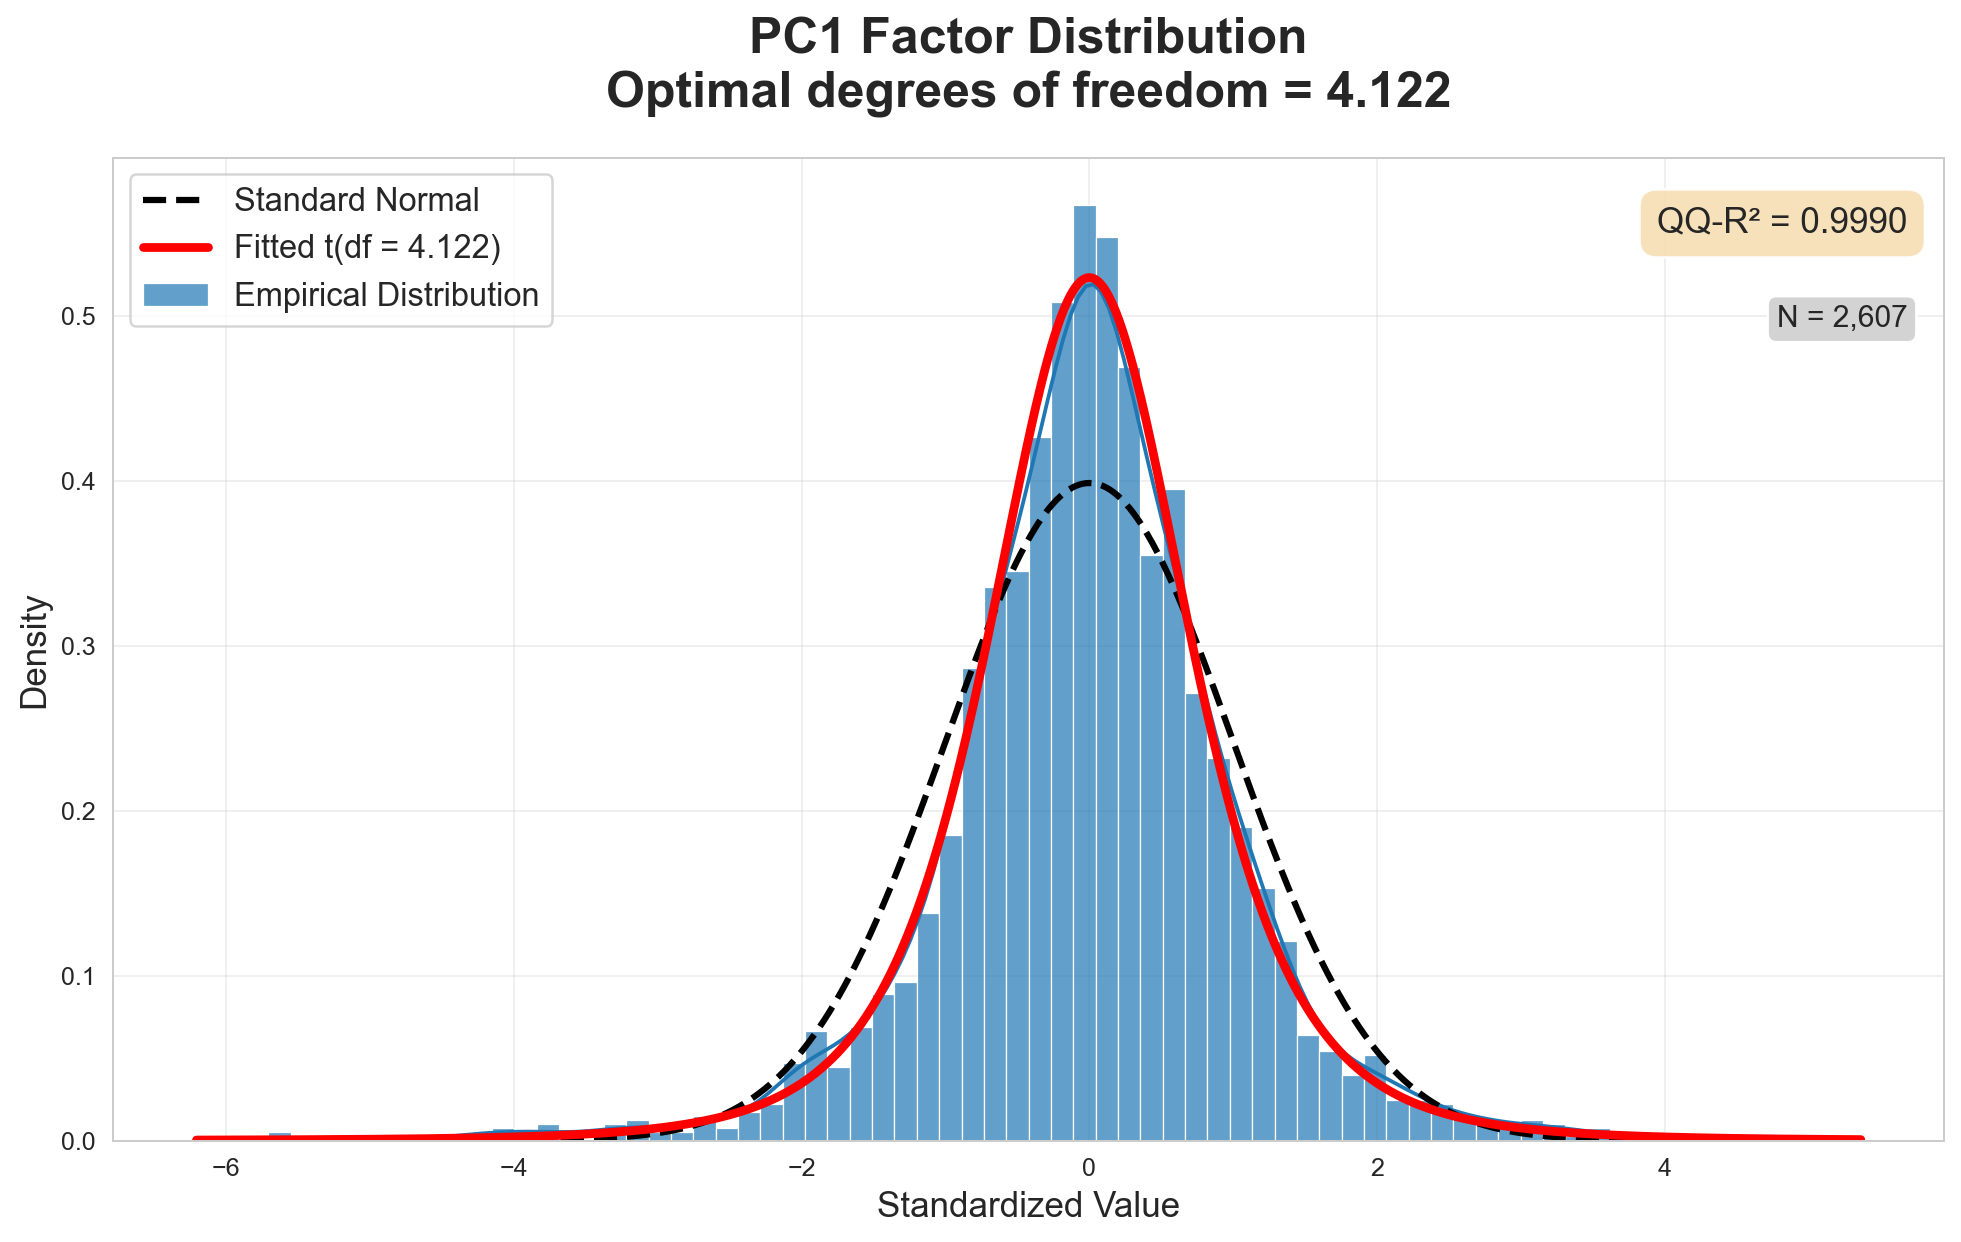

√ PC1 saved as: PC1_Distribution_Fitted_t_df4.122.png


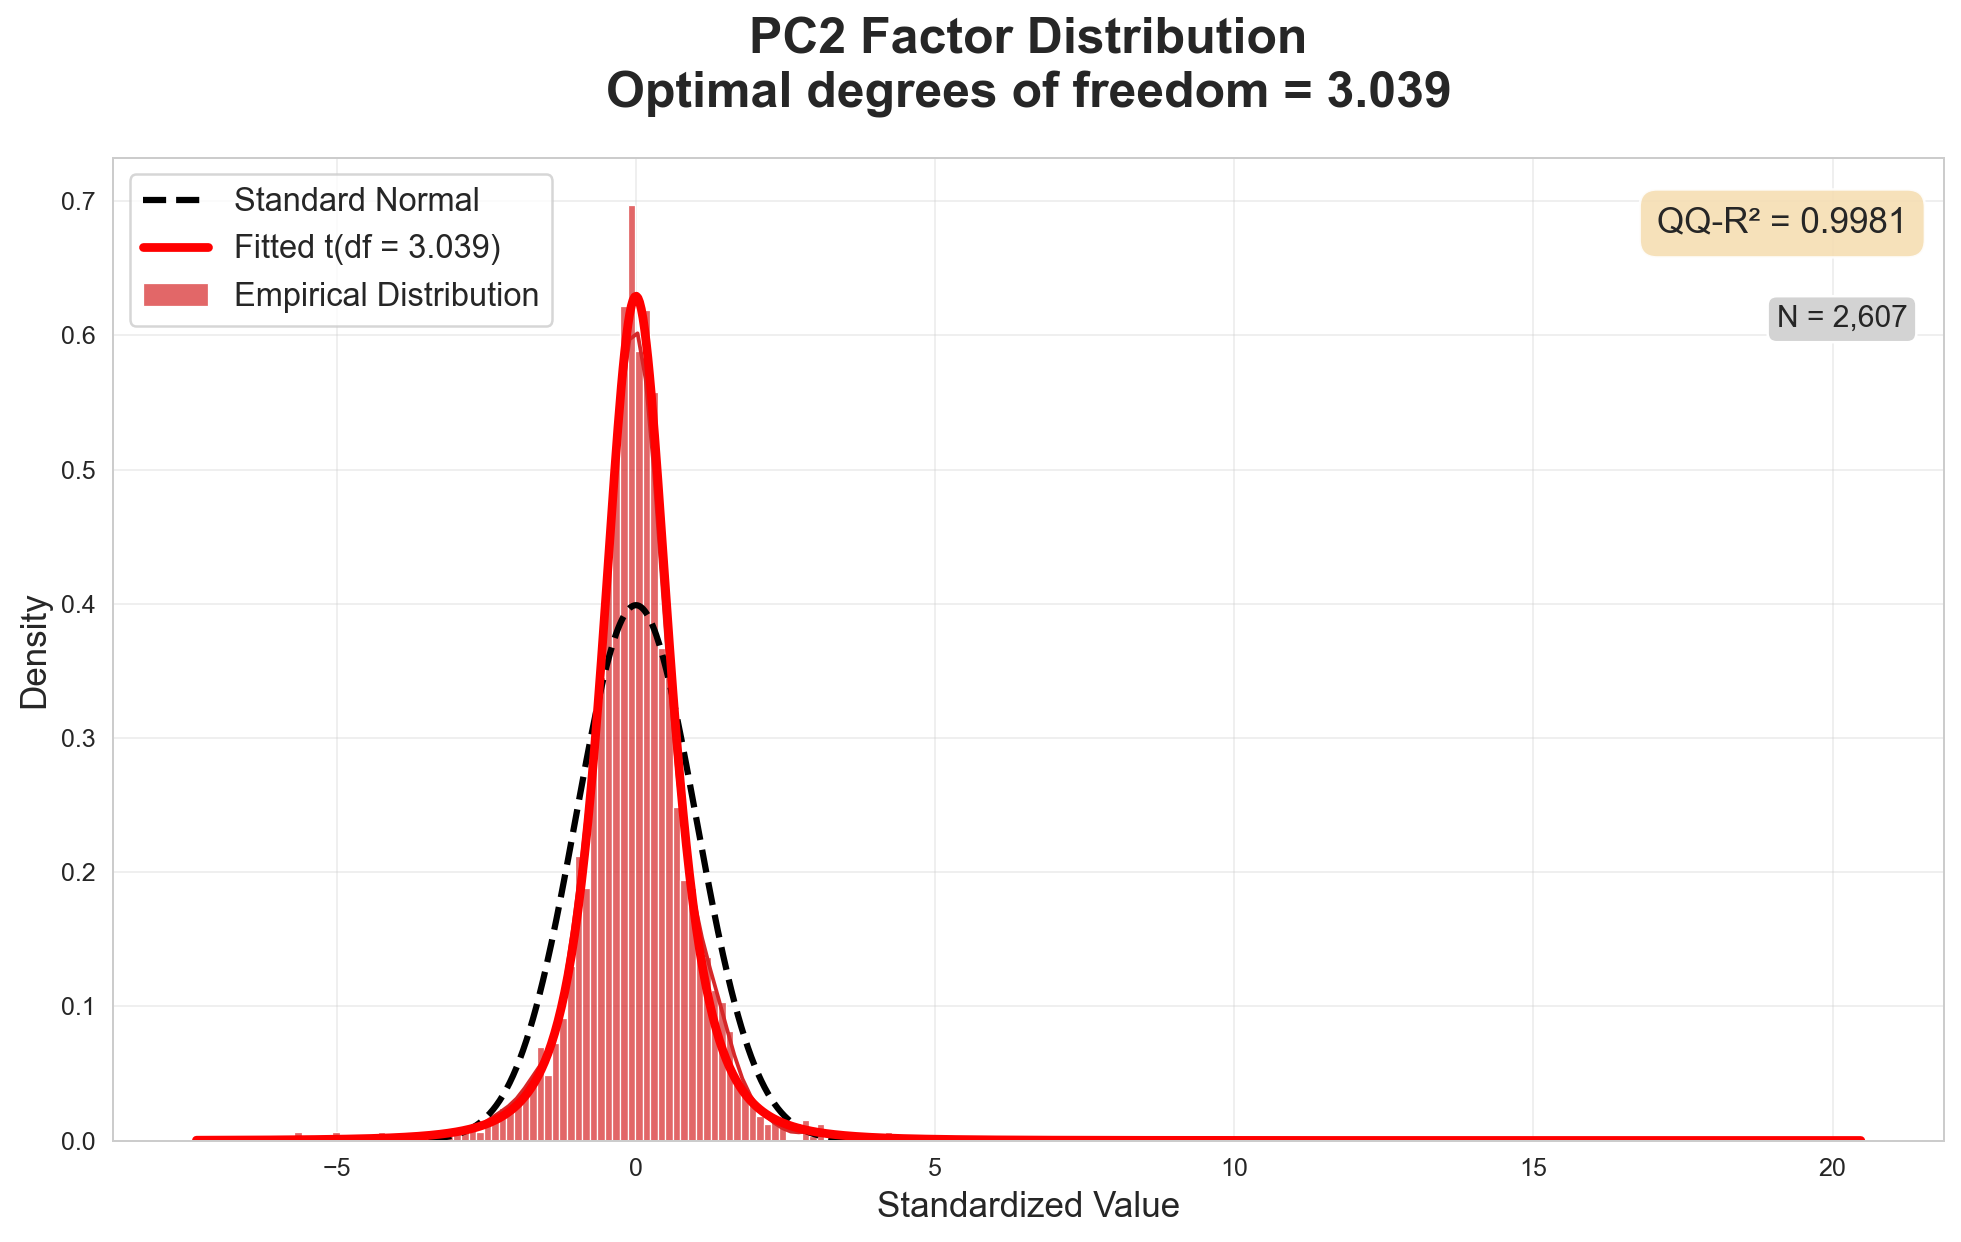

√ PC2 saved as: PC2_Distribution_Fitted_t_df3.039.png


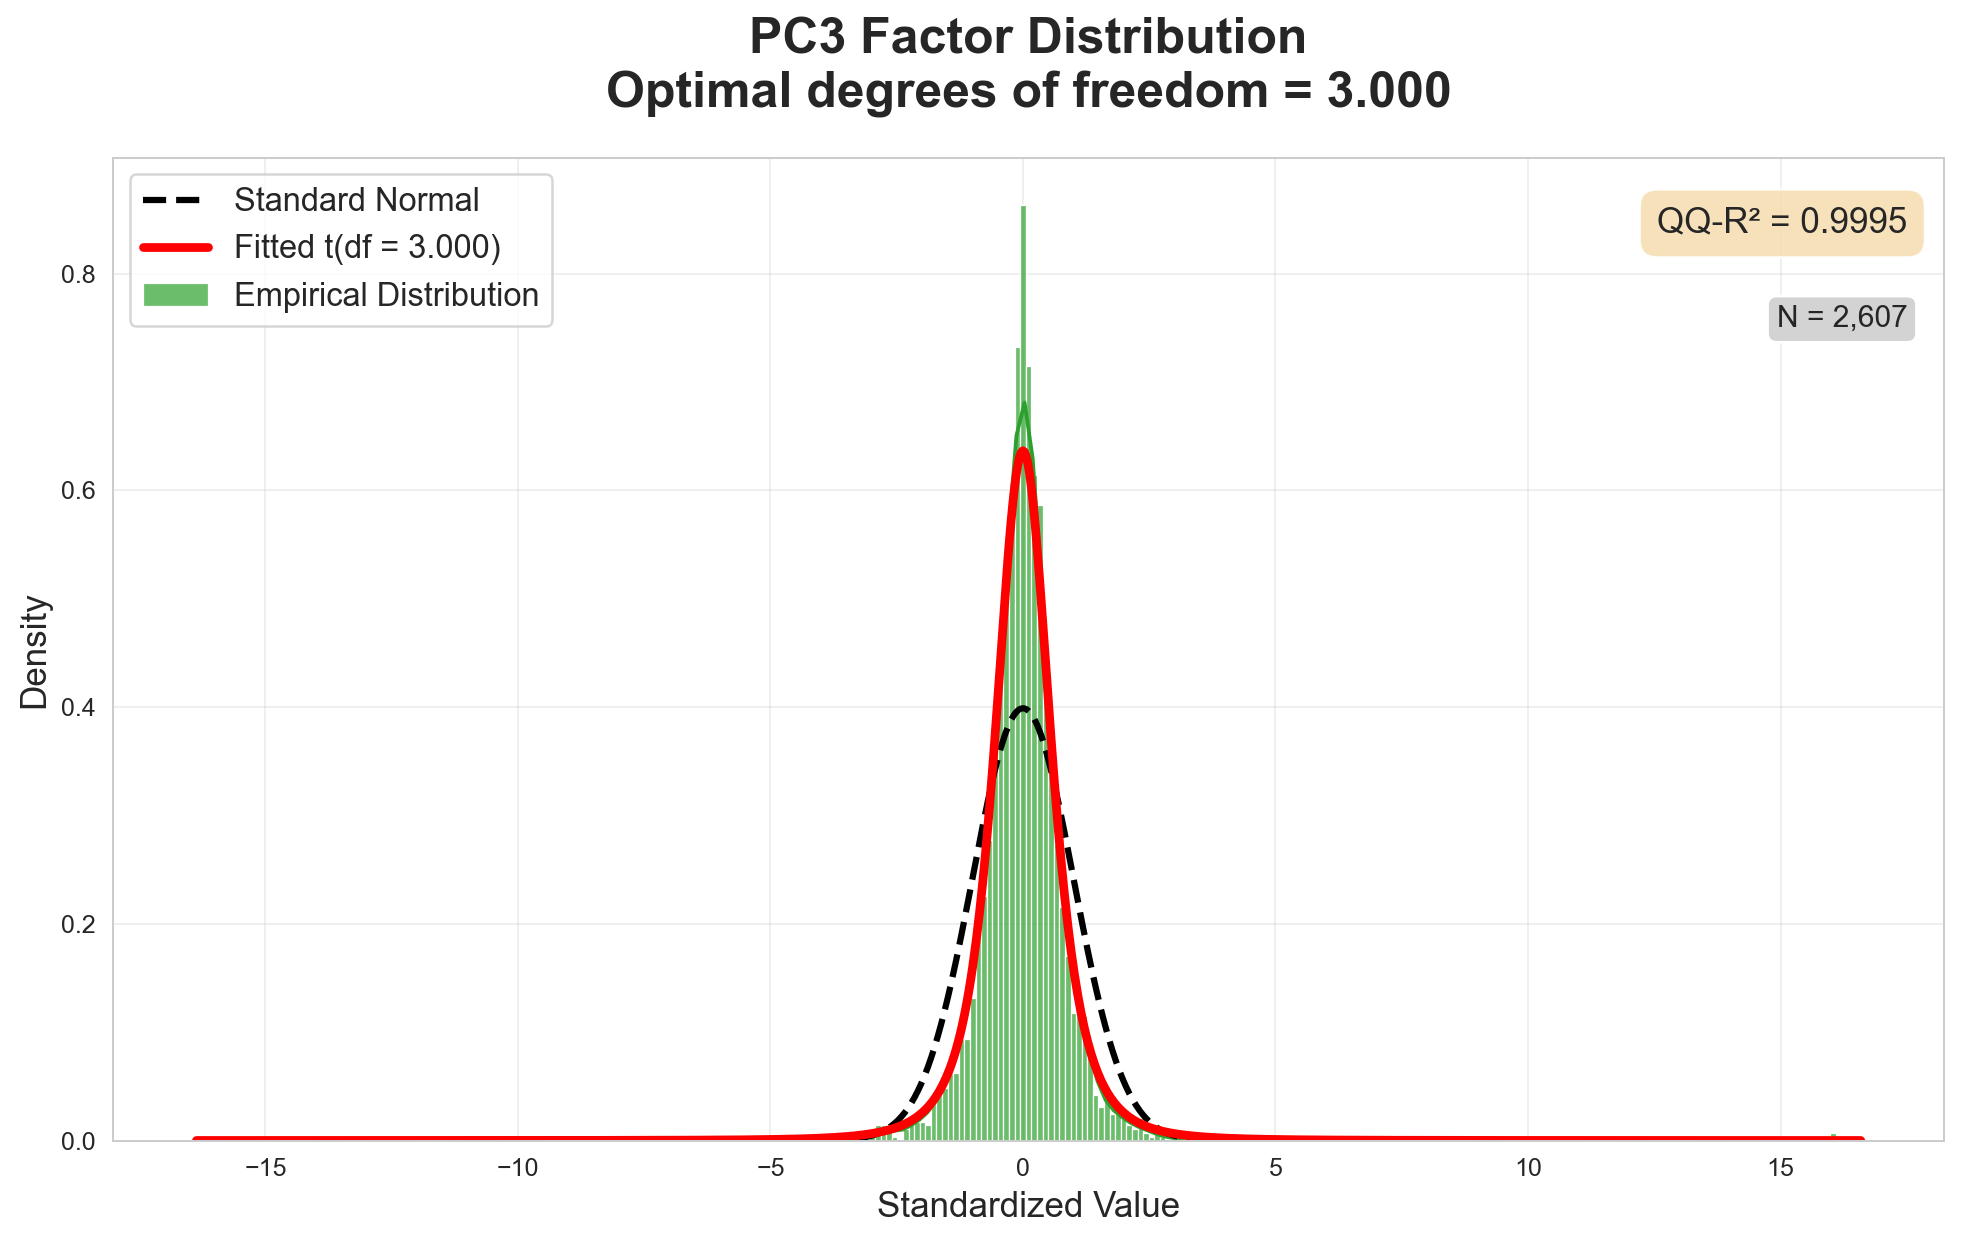

√ PC3 saved as: PC3_Distribution_Fitted_t_df3.000.png

All three professional English plots have been generated and saved!


In [24]:
# ================================
#      Histogram for each PC
# ================================
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

plt.rcParams['font.family'] = 'Arial'
sns.set_style("whitegrid")
colors = ["#1f77b4", "#d62728", "#2ca02c"]

for idx, pc in enumerate(pc_names_K):         # PC1, PC2, PC3
    data = factor_df[pc].dropna().values
    x_std = (data - data.mean()) / data.std()
    df    = optimal_dfs[pc]
    scale = np.sqrt((df - 2) / df) if df > 2 else 1.0

    # ---- plot ----
    plt.figure(figsize=(11, 7), dpi=180)

    # Histogram + KDE
    sns.histplot(x_std, bins='fd', kde=True, stat="density",
                 color=colors[idx], alpha=0.7, edgecolor="white", linewidth=0.5,
                 label="Empirical Distribution")

    # Normal
    xmin, xmax = x_std.min() - 0.5, x_std.max() + 0.5
    x_grid = np.linspace(xmin, xmax, 1000)
    plt.plot(x_grid, stats.norm.pdf(x_grid, 0, 1),
             color='black', linestyle='--', linewidth=2.5, label="Standard Normal")

    # Fitted t-distribution
    plt.plot(x_grid, stats.t.pdf(x_grid, df=df, loc=0, scale=scale),
             color='red', linewidth=3.5, label=f"Fitted t(df = {df:.3f})")

    plt.title(f"{pc} Factor Distribution\n"
              f"Optimal degrees of freedom = {df:.3f}",
              fontsize=20, fontweight='bold', pad=20)
    plt.xlabel("Standardized Value", fontsize=14)
    plt.ylabel("Density", fontsize=14)
    plt.legend(fontsize=13)

    # QQ-R²
    theo = stats.t.ppf(np.linspace(0.01, 0.99, len(x_std)), df=df, scale=scale)
    emp  = np.percentile(x_std, np.linspace(1, 99, len(x_std)))
    r2 = stats.linregress(theo, emp).rvalue ** 2
    plt.text(0.98, 0.95, f"QQ-R² = {r2:.4f}", transform=plt.gca().transAxes,
             fontsize=14, ha='right', va='top',
             bbox=dict(boxstyle="round,pad=0.5", facecolor="wheat", alpha=0.9))

    # Sample size
    plt.text(0.98, 0.85, f"N = {len(x_std):,}", transform=plt.gca().transAxes,
             fontsize=12, ha='right', va='top',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"))

    plt.grid(alpha=0.3)
    plt.tight_layout()

    # Save
    plt.savefig(f"{pc}_Distribution_Fitted_t_df{df:.3f}.png",
                dpi=300, bbox_inches='tight')
    plt.show()

    print(f"√ {pc} saved as: {pc}_Distribution_Fitted_t_df{df:.3f}.png")

print("\nAll three professional English plots have been generated and saved!")


In [25]:
# ========= read daily zero curve sheet =========
ZERO_FILE_WIDE = "./zero_curve_14to25.xlsx"

zero_wide = pd.read_excel(ZERO_FILE_WIDE, parse_dates=["Date"])
zero_wide = zero_wide.sort_values("Date").set_index("Date")

zero_wide_pca = zero_wide[TENOR_COLS].astype(float)


# ========= column → tenors =========
import re

def tenor_to_years(col_name: str) -> float:
    s = str(col_name).strip().upper()
    if s == "ON":
        return 1.0 / 360.0
    m = re.fullmatch(r"(\d+)([WMY])", s)
    if m:
        n = float(m.group(1))
        unit = m.group(2)
        if unit == "W":
            return n * 7.0 / 360.0
        elif unit == "M":
            return n / 12.0
        elif unit == "Y":
            return n
    raise ValueError(f"cannot convert: {col_name}")

maturity_years = {tenor: tenor_to_years(tenor) for tenor in zero_wide.columns}


In [26]:
# ========= Model PCA: Normal Distribution =========

#def simulate_delta_zero_pca(n_paths: int, rng=None):
#    """
#    simulate n_paths 1-day Δ
#    """
#    if rng is None:
#        rng = np.random.default_rng()

    # stardard normal eps: K dimension
#    eps = rng.standard_normal(size=(n_paths, K))   # n_paths × K

    #  F ~ N(mu_f, Sigma_f)
 #   F = mu_f + eps @ L.T                           # n_paths × K

    # Δz = B f
    # B: M × K, F: n_paths × K ==> Δz: n_paths × M
 #   delta_z = F @ B.T

 #   return delta_z  # shape: (n_paths, M)


def simulate_zero_curves_for_date(valuation_date, n_paths=10000, rng=None):
    """
    for valuation_date:
      - read corresponding zero curve（%）
      - using PCA model simulate n_paths 1-day Δzero
      - return zero matrix

    ret:
      zero_scenarios: ndarray, shape (n_paths, M)
    """
    if rng is None:
        rng = np.random.default_rng()

    # time t zero（%）
    z_today_pct = zero_wide_pca.loc[valuation_date, :].values  # shape: (M,)

    # simulate Δzero（%）
    delta_z_pct = simulate_delta_zero_pca(n_paths, rng=rng)    # n_paths × M

    # t+1 zero（%）
    z_tomorrow_pct = z_today_pct[None, :] + delta_z_pct        # broadcast

    # convert it to decimals for future calculation
    z_tomorrow_dec = z_tomorrow_pct / 100.0

    return z_tomorrow_dec, z_today_pct / 100.0  # (scenario matrix, today zero in decimal)


In [27]:
# ========= Getting discounting factors from zero curve =========

def build_zero_curve_dict(zero_row_dec):
    """
    zero_row_dec: 1D ndarray, TENOR_COLS zero rate（dec）
    ret: dict { maturity_in_years: zero_rate_decimal }
    """
    curve_dict = {}
    for tenor, z in zip(TENOR_COLS, zero_row_dec):
        T = maturity_years[tenor]
        curve_dict[T] = z
    return curve_dict


def get_zero_at_T(curve_dict, T_target):
    Ts = np.array(sorted(curve_dict.keys()))
    zs = np.array([curve_dict[T] for T in Ts])

    if T_target <= Ts[0]:
        return zs[0]
    if T_target >= Ts[-1]:
        return zs[-1]

    idx = np.searchsorted(Ts, T_target)
    T1, T2 = Ts[idx-1], Ts[idx]
    z1, z2 = zs[idx-1], zs[idx]
    w = (T_target - T1) / (T2 - T1)
    return z1 + w * (z2 - z1)


def discount_factor(curve_dict, T):

    z = get_zero_at_T(curve_dict, T)
    return (1.0 + z / 360) ** (-T * 360)
#    return np.exp(-z * T)
#    return (1.0 + z) ** (-T)


# ==========================
#   read sheet
# ==========================
FILE_PATH = r"./SOFR_SWAP.wide.filled.xls"
df_raw = pd.read_csv(FILE_PATH, sep="\t")
#df_raw["Date"] = pd.to_datetime(df_raw["Date"], format='%Y/%m/%d').dt.tz_localize(None)  # 强制无时区
df_raw["Date"] = pd.to_datetime(df_raw["Date"])
df = df_raw.set_index("Date").sort_index()

# ==========================
#  5Y SOFR Swap Par Rate
# ==========================
sofr_5y_par_rate_hist = df["5Y"].copy()

sofr_5y_par_rate_hist = sofr_5y_par_rate_hist.asfreq('B').ffill()

# ==========================
#  taking values from the sheet
# ==========================
def get_5y_sofr_par_rate(val_date) -> float:
    """
    enter any date，return real 5Y SOFR swap par rate
    """
    return sofr_5y_par_rate_hist.asof(val_date)


def swap_5y_pv(curve_dict, fixed_rate, notional=1.0):
    """
    given zero curve and fixed rate，calculate 5Y swap PV
    PV = PV(floating) - PV(fixed)
    """
    pay_dates = np.array([1, 2, 3, 4, 5], dtype=float)
    alpha = np.ones_like(pay_dates)

    dfs = np.array([discount_factor(curve_dict, T) for T in pay_dates])

    # PV for fixed leg
    pv_fixed = fixed_rate * np.sum(alpha * dfs) * notional

    # PV for floating leg
    pv_float = (1.0 - dfs[-1]) * notional

#    return pv_fixed - pv_float           #if fixed-receiver, then open this
    return pv_float - pv_fixed


In [28]:
# ========= Monte Carlo VaR & ES =========

def mc_var_es_for_date(valuation_date,
                       notional=1_000_000,
                       alpha=0.99,
                       n_paths=10000,
                       rng=None,
                       pv_today_mkt=None):
    """
    for any valuation_date:
      1. using zero curve to get par rate K*;
      2. if pv_today_mkt，then use it to calculate PV；
         otherwise using par swap PV（≈0；
      3. using PCA model to simulate t+1 zero curve，calculate t+1 swap PV；
      4. Getting P&L distribution，measure VaR & ES。

    return: dict incl. base_PV（for P&L）
    """
    if rng is None:
        rng = np.random.default_rng()

    # ---- day t zero → zero curve dict ----
    z_today_dec = zero_wide_pca.loc[valuation_date, :].values / 100.0
    curve_today = build_zero_curve_dict(z_today_dec)

    # ---- calculate par fixed rate K* ----
    K_par = get_5y_sofr_par_rate(valuation_date)

    # ---- par swap PV（≈ 0） ----
    base_pv_model = swap_5y_pv(curve_today, fixed_rate=K_par, notional=notional)

    # ---- choosing P&L PV ----
    if pv_today_mkt is None:
        base_pv = base_pv_model
    else:
        base_pv = float(pv_today_mkt)

    # ---- simulate t+1 zero curve ----
    z_tomorrow_scenarios, _ = simulate_zero_curves_for_date(
        valuation_date,
        n_paths=n_paths,
        rng=rng
    )  # shape: (n_paths, len(TENOR_COLS))

    # ---- pricing swap for each path, getting t+1 PV_scenarios ----
    pv_scenarios = np.empty(n_paths)

    for k in range(n_paths):
        curve_k = build_zero_curve_dict(z_tomorrow_scenarios[k, :])
        pv_scenarios[k] = swap_5y_pv(curve_k, fixed_rate=K_par, notional=notional)

    # ---- P&L ----
    pnl = pv_scenarios - base_pv
    loss = -pnl

    # ---- VaR / ES（distribution）----
    loss_sorted = np.sort(loss)
    n = len(loss_sorted)
    idx_var = int(np.floor(alpha * n)) - 1
    idx_var = max(0, min(idx_var, n - 1))
    var_alpha = loss_sorted[idx_var]
    tail_losses = loss_sorted[idx_var:]
    es_alpha = tail_losses.mean()

    return {
        "valuation_date": valuation_date,
        "notional": notional,
        "K_par": K_par,
        "base_pv_model": base_pv_model,   # calculated PV（as reference）
        "base_pv": base_pv,               # real P&L PV
        "VaR": var_alpha,
        "ES": es_alpha,
        "loss_series": loss,
        "pv_scenarios": pv_scenarios,
    }
# ===== examples =====
# result = mc_var_es_for_date("2022-12-30", notional=1_000_000, alpha=0.99, n_paths=20000)
# print(result["base_pv"], result["VaR"], result["ES"])

In [29]:
result = mc_var_es_for_date(
    "2025-11-14",
    notional=1_000_000,
    alpha=0.99,
    n_paths=10000,
    pv_today_mkt=0
)
print(result["base_pv"], result["VaR"], result["ES"])

0.0 3359.266923989315 5713.059098476978


In [30]:
import numpy as np
import pandas as pd

# ========== setting ==========
VAL_DATE      = pd.Timestamp("2025-11-14")   # settlement date（Nov 14，Friday）
NOTIONAL      = 1_000_000                    # notional principle
N_SCENARIOS   = 10_000                       # paths
HORIZON_DAYS  = 1                            # 1 trading dat（14→17）

rng = np.random.default_rng(2025)

# ======= known：day 14 PV & 5Y fixed rate（3.41615%）=======
PV_BASE_MKT_14   = 0   # 5Y swap with PV=0 at inception
FIXED_RATE_5Y    = 0.0341615    # 3.41615% fixed leg（from contract quote）

# ========== on Nov 14 zero curve ==========
z_today_dec = zero_wide_pca.loc[VAL_DATE, :].values / 100.0
curve_today = build_zero_curve_dict(z_today_dec)

PV_base_model = swap_5y_pv(curve_today,
                           fixed_rate = FIXED_RATE_5Y,
                           notional   = NOTIONAL)

# Calculate P&L
PV_base = PV_BASE_MKT_14

# ========== Simulate next trading day zero & calculate PV_scenarios ==========
z_future_scenarios, _ = simulate_zero_curves_for_date(
    VAL_DATE,
    n_paths      = N_SCENARIOS,
    # horizon_days = HORIZON_DAYS,
    rng          = rng
)  # shape: (N_SCENARIOS, len(TENOR_COLS))

PV_array  = np.empty(N_SCENARIOS)
for k in range(N_SCENARIOS):
    curve_k = build_zero_curve_dict(z_future_scenarios[k, :])
    # using 3.41615% as fixed rate
    PV_array[k] = swap_5y_pv(curve_k,
                             fixed_rate = FIXED_RATE_5Y,
                             notional   = NOTIONAL)

# ========== P&L_scenarios ==========
# P&L = PV of Nov 17 - PV of 14”
PnL_array = PV_array - PV_base    # P&L = V_future − V_14(market)

# ========== Save ==========
np.save("pv_scenarios_14to17.npy",  PV_array)
np.save("pnl_scenarios_14to17.npy", PnL_array)

pv_scenarios = np.load("pv_scenarios_14to17.npy")
pnl_scenarios = np.load("pnl_scenarios_14to17.npy")

df = pd.DataFrame({
    "scenario_id":  np.arange(len(pv_scenarios)),
    "PV_tomorrow":  pv_scenarios,
    "PnL":          pnl_scenarios,
    "Loss":         -pnl_scenarios
})

df.to_excel("pv_pnl_scenarios_14to17.xlsx", index=False)
print("saved PV + PnL + Loss to Excel")

summ = pd.Series({
    "val_date":          str(VAL_DATE.date()),
    "horizon_days":      int(HORIZON_DAYS),
    "scenarios":         int(N_SCENARIOS),
    "pv_base_model_14":  float(PV_base_model),
    "pv_base_market_14": float(PV_base),
    "fixed_rate_5Y":     float(FIXED_RATE_5Y),
    "pnl_mean":          float(np.mean(PnL_array)),
    "pnl_std":           float(np.std(PnL_array, ddof=1)),
    "pnl_min":           float(np.min(PnL_array)),
    "pnl_max":           float(np.max(PnL_array)),
})
summ.to_frame("value").to_csv("mc_14to17_summary.csv")

print("Monte Carlo done（14 → 17，next trading day）：")
print(summ)
print("file saved：pv_scenarios_14to17.npy / pnl_scenarios_14to17.npy / mc_14to17_summary.csv")


saved PV + PnL + Loss to Excel
Monte Carlo done（14 → 17，next trading day）：
val_date               2025-11-14
horizon_days                    1
scenarios                   10000
pv_base_model_14      3124.030222
pv_base_market_14             0.0
fixed_rate_5Y            0.034161
pnl_mean              3147.557811
pnl_std               2419.051169
pnl_min             -14815.292214
pnl_max              21760.664148
dtype: object
file saved：pv_scenarios_14to17.npy / pnl_scenarios_14to17.npy / mc_14to17_summary.csv


In [31]:
# ========== 5. using PnL cal VaR & ES ==========

ALPHAS = [0.95, 0.99]   # confidence level

loss_array = -PnL_array          # loss = -P&L
loss_sorted = np.sort(loss_array)

rows = []
n = len(loss_sorted)

for alpha in ALPHAS:
    idx = int(np.floor(alpha * n)) - 1
    idx = max(min(idx, n - 1), 0)

    var_alpha = loss_sorted[idx]
    es_alpha  = loss_sorted[idx:].mean()

    rows.append({
        "alpha": alpha,
        "VaR":   var_alpha,
        "ES":    es_alpha
    })

var_es_df = pd.DataFrame(rows)

var_es_df.to_csv("mc_var_es_table.csv", index=False)

print("\nVaR/ES（loss positive）：")
print(var_es_df)



VaR/ES（loss positive）：
   alpha          VaR           ES
0   0.95   576.016392  2365.047489
1   0.99  3316.611677  5511.672362


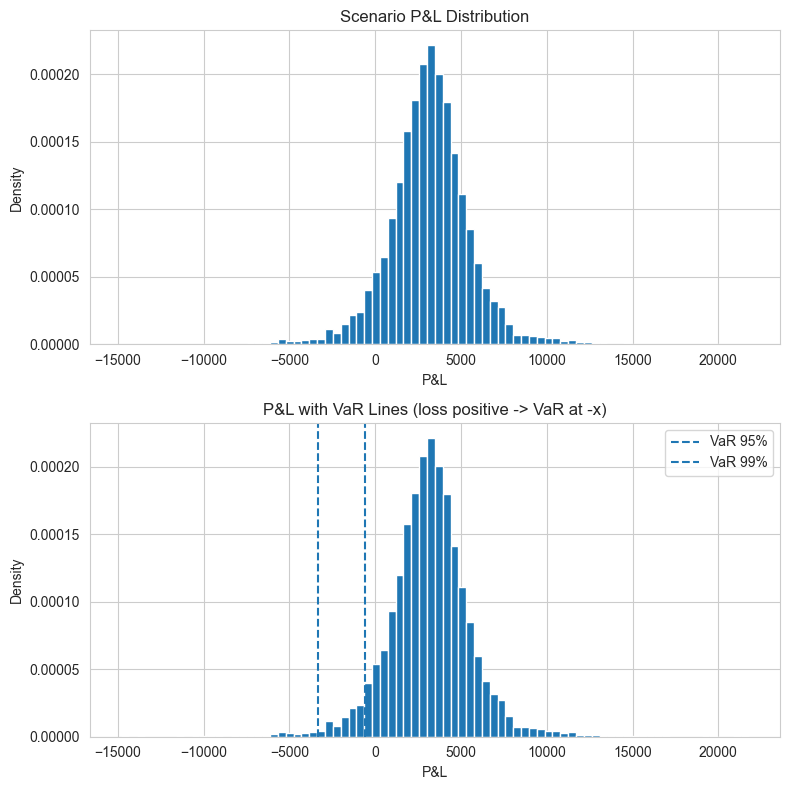

In [32]:
import matplotlib.pyplot as plt

# taking VaR above
VaR_95 = var_es_df.loc[var_es_df["alpha"] == 0.95, "VaR"].iloc[0]
VaR_99 = var_es_df.loc[var_es_df["alpha"] == 0.99, "VaR"].iloc[0]

plt.figure(figsize=(8, 8))

# ---------- P&L histogram ----------
plt.subplot(2, 1, 1)
plt.hist(PnL_array, bins=80, density=True)
plt.title("Scenario P&L Distribution")
plt.xlabel("P&L")
plt.ylabel("Density")

# ---------- VaR line P&L histogram ----------
plt.subplot(2, 1, 2)
plt.hist(PnL_array, bins=80, density=True)

# loss positive, VaR positive
plt.axvline(-VaR_95, linestyle="--", label="VaR 95%")
plt.axvline(-VaR_99, linestyle="--", label="VaR 99%")

plt.title("P&L with VaR Lines (loss positive -> VaR at -x)")
plt.xlabel("P&L")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
# plt.show()


In [33]:
import numpy as np
import pandas as pd


np.random.seed(2025)
N_SHOW = 10

# random 10 scenarios
idx = np.random.choice(z_future_scenarios.shape[0], size=N_SHOW, replace=False)
idx.sort()

sample_dec = pd.DataFrame(
    z_future_scenarios[idx, :],
    columns=TENOR_COLS        # 比如 ["1Y","2Y",...,"10Y"]
)

sample_pct = sample_dec * 100.0
sample_pct.insert(0, "scenario_id", idx)

print("Sample of simulated 17th zero curves (rates in %):")
print(sample_pct.round(4).to_string(index=False))


Sample of simulated 17th zero curves (rates in %):
 scenario_id     1Y     2Y     3Y     4Y     5Y     6Y     7Y     8Y     9Y    10Y    12Y    15Y
         984 3.5875 3.3813 3.3347 3.3495 3.3902 3.4479 3.5127 3.5786 3.6441 3.7089 3.8304 3.9842
        1457 3.6020 3.4144 3.3786 3.3994 3.4432 3.5012 3.5658 3.6307 3.6957 3.7591 3.8685 4.0283
        3544 3.5759 3.3597 3.3073 3.3186 3.3573 3.4142 3.4785 3.5447 3.6101 3.6754 3.8011 3.9532
        3600 3.5799 3.3671 3.3209 3.3391 3.3845 3.4477 3.5164 3.5858 3.6543 3.7224 3.8612 4.0069
        3904 3.7687 3.5641 3.4757 3.4502 3.4560 3.4867 3.5323 3.5824 3.6348 3.6877 3.7918 3.9290
        6448 3.5762 3.4066 3.3883 3.4209 3.4721 3.5331 3.5997 3.6652 3.7310 3.7940 3.8876 4.0608
        6938 3.5985 3.4089 3.3748 3.3985 3.4457 3.5072 3.5744 3.6414 3.7082 3.7735 3.8923 4.0479
        8295 3.6064 3.4070 3.3660 3.3865 3.4328 3.4958 3.5640 3.6322 3.7001 3.7671 3.9002 4.0466
        9586 3.6052 3.4204 3.3926 3.4230 3.4766 3.5440 3.6151 3.6850 3.7545 

In [34]:
import numpy as np
import pandas as pd

# ========= Backtest 配置 =========
NOTIONAL       = 1_000_000         # NP
N_PATHS        = 50_000            # Paths
ALPHAS         = [0.95, 0.99]      # 95% & 99% VaR/ES
BACKTEST_START = "2024-01-02"      # Start date of backtesting
BACKTEST_END   = "2025-11-14"      # End date of backtesting
RNG_SEED       = 2025

rng = np.random.default_rng(RNG_SEED)


# ========= Cal VaR / ES =========
def var_es_from_loss(loss_array, alpha=0.99):
    """
    loss_array: ndarray
    alpha: confidence level, like 0.99
    ret: (VaR_alpha, ES_alpha)
    """
    x = np.sort(loss_array)
    n = len(x)
    k = int(np.floor(alpha * n)) - 1
    k = max(0, min(k, n - 1))
    VaR = x[k]
    ES  = x[k:].mean() if k < n else x[k]
    return float(VaR), float(ES)


In [35]:

ZERO_FILE_WIDE = "./zero_curve_14to25.xlsx"

zero_wide = pd.read_excel(ZERO_FILE_WIDE, parse_dates=["Date"])
zero_wide = zero_wide.sort_values("Date").set_index("Date")

zero_wide_pca = zero_wide[TENOR_COLS].astype(float)


In [36]:
# ========= Backtest =========

dates = zero_wide_pca.loc[BACKTEST_START:BACKTEST_END].index
dates = dates.sort_values()

records = []

for i in range(len(dates) - 1):
    val_date  = dates[i]
    next_date = dates[i + 1]

    # ---------- Cal VaR/ES for date ----------
    res_mc = mc_var_es_for_date(
        valuation_date = val_date,
        notional       = NOTIONAL,
        alpha          = ALPHAS[-1],
        n_paths        = N_PATHS,
        rng            = rng
    )

    base_pv   = res_mc["base_pv"]
    K_par     = res_mc["K_par"]
    loss_mc   = res_mc["loss_series"]

    var_dict = {}
    es_dict  = {}
    for a in ALPHAS:
        VaR_a, ES_a = var_es_from_loss(loss_mc, alpha=a)
        key_v = f"VaR_{int(a*100)}"
        key_e = f"ES_{int(a*100)}"
        var_dict[key_v] = VaR_a
        es_dict[key_e]  = ES_a

    # ---------- cal "real next-day P&L" ----------
    # day t zero
    z_today_dec = zero_wide_pca.loc[val_date, :].values / 100.0
    curve_today = build_zero_curve_dict(z_today_dec)

    # next day zero
    z_next_dec  = zero_wide_pca.loc[next_date, :].values / 100.0
    curve_next  = build_zero_curve_dict(z_next_dec)

    K_par_real  = get_5y_sofr_par_rate(val_date)

    pv_t   = swap_5y_pv(curve_today, fixed_rate=K_par_real, notional=NOTIONAL)
    pv_tp1 = swap_5y_pv(curve_next,  fixed_rate=K_par_real, notional=NOTIONAL)

    pnl_real  = pv_tp1 - pv_t
    loss_real = -pnl_real

    # ---------- Record ----------
    rec = {
        "date":       val_date,
        "pv_base":    base_pv,
        "pnl_real":   pnl_real,
        "loss_real":  loss_real,
        "K_par":      K_par_real,
        "next_date":  next_date
    }
    rec.update(var_dict)
    rec.update(es_dict)

    records.append(rec)

    if i % 20 == 0:
        print(f"{val_date.date()} done; next_date={next_date.date()}")

bt_df = pd.DataFrame(records).set_index("date")
bt_df.to_csv("backtest_simple_var_es.csv")
print("\nBacttesing save to backtest_simple_var_es.csv")
bt_df.head()


2024-01-02 done; next_date=2024-01-03
2024-01-30 done; next_date=2024-01-31
2024-02-27 done; next_date=2024-02-28
2024-03-26 done; next_date=2024-03-27
2024-04-23 done; next_date=2024-04-24
2024-05-21 done; next_date=2024-05-22
2024-06-18 done; next_date=2024-06-19
2024-07-16 done; next_date=2024-07-17
2024-08-13 done; next_date=2024-08-14
2024-09-10 done; next_date=2024-09-11
2024-10-08 done; next_date=2024-10-09
2024-11-05 done; next_date=2024-11-06
2024-12-03 done; next_date=2024-12-04
2024-12-31 done; next_date=2025-01-01
2025-01-28 done; next_date=2025-01-29
2025-02-25 done; next_date=2025-02-26
2025-03-25 done; next_date=2025-03-26
2025-04-22 done; next_date=2025-04-23
2025-05-20 done; next_date=2025-05-21
2025-06-17 done; next_date=2025-06-18
2025-07-15 done; next_date=2025-07-16
2025-08-12 done; next_date=2025-08-13
2025-09-09 done; next_date=2025-09-10
2025-10-07 done; next_date=2025-10-08
2025-11-04 done; next_date=2025-11-05

Bacttesing save to backtest_simple_var_es.csv


,pv_base,pnl_real,loss_real,K_par,next_date,VaR_95,VaR_99,ES_95,ES_99
date,,,,,,,,,
2024-01-02,3561.780748,270.174695,-270.174695,0.035925,2024-01-03,3653.958386,6392.509722,5470.087233,8980.974750
2024-01-03,3577.570427,4016.706728,-4016.706728,0.035982,2024-01-04,3683.246892,6426.830034,5470.383216,8865.055094
2024-01-04,3735.964894,1002.685258,-1002.685258,0.036848,2024-01-05,3628.726074,6291.469715,5395.323349,8677.132030
2024-01-05,3770.470172,472.859855,-472.859855,0.037066,2024-01-08,3680.534137,6414.696573,5453.314607,8808.676434
2024-01-08,3789.388008,-1048.648437,1048.648437,0.037168,2024-01-09,3618.386276,6173.810430,5314.342374,8522.695499


In [37]:
# ========= Kupiec POF test（99% VaR） =========

from scipy.stats import chi2

alpha_main = 0.99
var_col    = f"VaR_{int(alpha_main*100)}"

exceed = (bt_df["loss_real"] > bt_df[var_col]).astype(int)
Tn = len(exceed)
x  = int(exceed.sum())
p_hat = x / Tn

p_theory = 1.0 - alpha_main   # theoritical exception, 0.01

def safe_log(x):
    x = float(x)
    return -1e9 if x <= 0 else np.log(x)

LR_pof = -2.0 * (
    (Tn-x)*safe_log(1-p_theory) + x*safe_log(p_theory)
    - (Tn-x)*safe_log(1-p_hat)  - x*safe_log(p_hat)
)

p_value = chi2.sf(LR_pof, 1)

print("\nKupiec POF TEST：")
print(f"T = {Tn},  exceptions = {x},  exceed_ratio = {p_hat:.4%}")
print(f"LR_pof = {LR_pof:.4f}")
print(f"p-value = {p_value:.4f} → {'model accepted' if p_value > 0.05 else 'model rejected'}")



Kupiec POF TEST：
T = 488,  exceptions = 5,  exceed_ratio = 1.0246%
LR_pof = 0.0030
p-value = 0.9566 → model accepted


In [38]:
# ========== Christoffersen (1998) Independence & Conditional Coverage Test ==========
#   - using Backtest result exceed（1 = loss_real > VaR, 0 = None）
#   - under H0, VaR exceed are independent Bernoulli(p)，
#     Christoffersen test independence

# exceed: pd.Series, 0/1
exc = exceed.astype(int).values
Tn  = len(exc)

# n00, n01, n10, n11
n00 = n01 = n10 = n11 = 0
for i in range(1, Tn):
    i_prev, i_now = int(exc[i-1]), int(exc[i])
    if   i_prev == 0 and i_now == 0: n00 += 1
    elif i_prev == 0 and i_now == 1: n01 += 1
    elif i_prev == 1 and i_now == 0: n10 += 1
    elif i_prev == 1 and i_now == 1: n11 += 1

# π0 = P(exceed_t = 1 | exceed_{t-1} = 0)
# π1 = P(exceed_t = 1 | exceed_{t-1} = 1)
den0 = n00 + n01
den1 = n10 + n11
pi0  = n01 / den0 if den0 > 0 else 0.0
pi1  = n11 / den1 if den1 > 0 else 0.0

den_all = n00 + n01 + n10 + n11
phat    = (n01 + n11) / den_all if den_all > 0 else 0.0

ll_ind = (
    n00 * safe_log(1 - pi0) +
    n01 * safe_log(pi0)     +
    n10 * safe_log(1 - pi1) +
    n11 * safe_log(pi1)
)

# i.i.d. Bernoulli(phat)
ll_iid = (
    (n00 + n10) * safe_log(1 - phat) +
    (n01 + n11) * safe_log(phat)
)

# Christoffersen
#   H0: independent，p_t = phat
#   H1: Markov process，p_t dependent on last exceed
LR_ind = -2.0 * (ll_iid - ll_ind)

# combine with Kupiec POF to get Conditional Coverage test
#   LR_cc = LR_pof + LR_ind
LR_cc = LR_pof + LR_ind

# p-values：LR_ind ~ χ²(1)，LR_cc ~ χ²(2)
p_ind = chi2.sf(LR_ind, df=1)
p_cc  = chi2.sf(LR_cc,  df=2)

print("\nChristoffersen (1998) Independence & Conditional Coverage TEST:")
print(f"n00={n00}, n01={n01}, n10={n10}, n11={n11}")
print(f"pi0 = P(exceed_t=1 | exceed_{'{t-1}'}=0) = {pi0:.4f}")
print(f"pi1 = P(exceed_t=1 | exceed_{'{t-1}'}=1) = {pi1:.4f}")
print(f"phat (overall exceed prob) = {phat:.4f}\n")

print(f"LR_ind  = {LR_ind:.4f},  p_ind  = {p_ind:.4f}  "
      f"({'no clustering (accept H0)' if p_ind > 0.05 else 'clustering detected (reject H0)'})")
print(f"LR_cc   = {LR_cc:.4f},  p_cc   = {p_cc:.4f}  "
      f"({'conditional coverage OK' if p_cc > 0.05 else 'conditional coverage rejected'})")



Christoffersen (1998) Independence & Conditional Coverage TEST:
n00=477, n01=5, n10=5, n11=0
pi0 = P(exceed_t=1 | exceed_{t-1}=0) = 0.0104
pi1 = P(exceed_t=1 | exceed_{t-1}=1) = 0.0000
phat (overall exceed prob) = 0.0103

LR_ind  = 0.1037,  p_ind  = 0.7474  (no clustering (accept H0))
LR_cc   = 0.1067,  p_cc   = 0.9481  (conditional coverage OK)


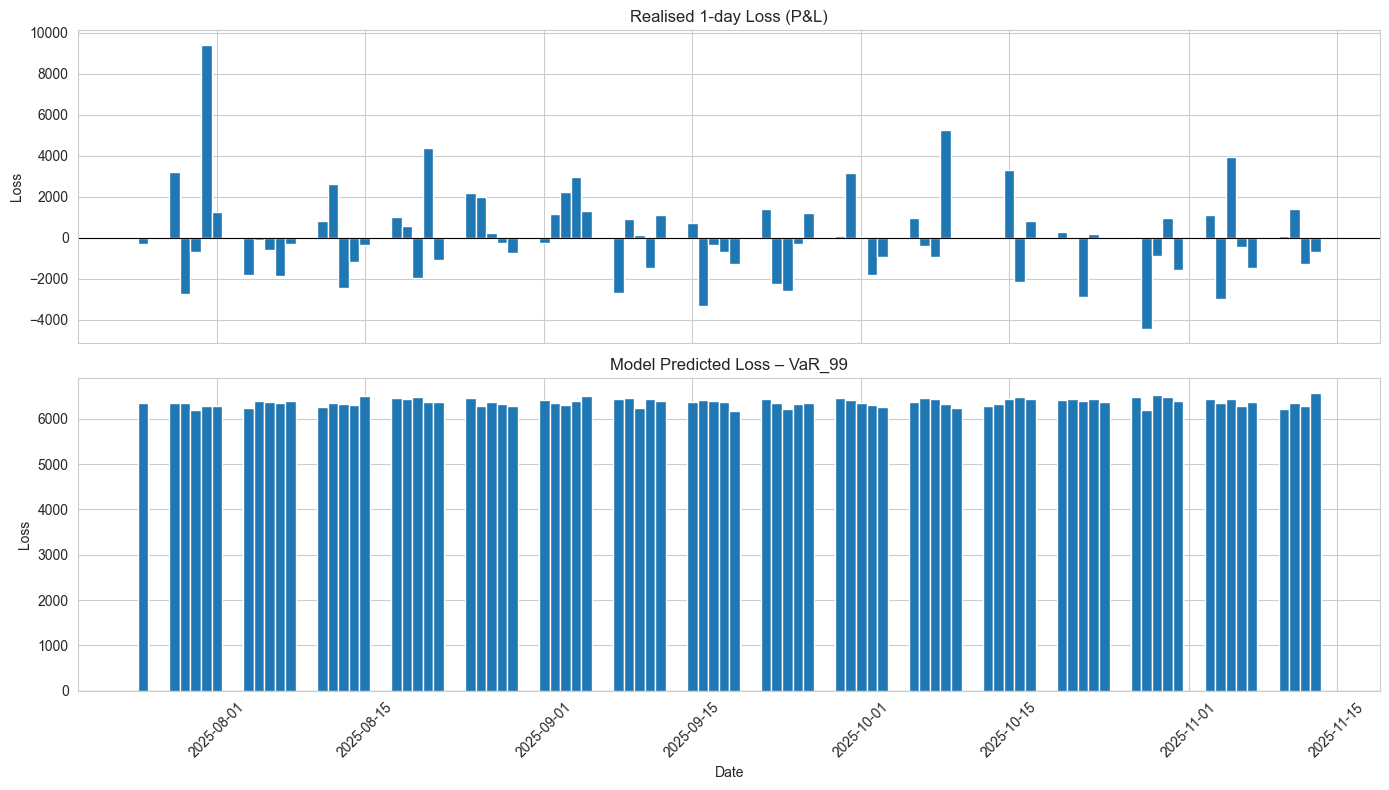

In [39]:
import matplotlib.pyplot as plt

# ========= set =========
N_SHOW = 80   # recent 80 trading days
bt_plot = bt_df.sort_index().copy()

if len(bt_plot) > N_SHOW:
    bt_plot = bt_plot.iloc[-N_SHOW:]

var_col = "VaR_99"    # or f"VaR_{int(ALPHAS[-1]*100)}"

# ========= Plot =========
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 1) real P&L（loss positive）
axes[0].bar(bt_plot.index, bt_plot["loss_real"], width=1.0)
axes[0].set_title("Realised 1-day Loss (P&L)", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=10)
axes[0].axhline(0, color="black", linewidth=0.8)

# 2) Estimated P&L by model（VaR）
axes[1].bar(bt_plot.index, bt_plot[var_col], width=1.0)
axes[1].set_title(f"Model Predicted Loss – {var_col}", fontsize=12)
axes[1].set_ylabel("Loss", fontsize=10)
axes[1].set_xlabel("Date", fontsize=10)
axes[1].axhline(0, color="black", linewidth=0.8)

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [40]:
import numpy as np
import pandas as pd

pv  = np.load("pv_scenarios_14to17.npy")
pnl = np.load("pnl_scenarios_14to17.npy")
summary = pd.read_csv("mc_14to17_summary.csv", index_col=0)

print("=== Monte Carlo Summary ===")
print(summary, "\n")

np.random.seed(2025)
idx = np.random.choice(len(pv), size=10, replace=False)
idx.sort()

sample = pd.DataFrame({
    "scenario_id": idx,
    "PV_scenario": pv[idx],
    "PnL_scenario": pnl[idx]
})

print("=== Sample of MC scenarios (10 paths) ===")
print(sample.to_string(index=False))


=== Monte Carlo Summary ===
                                 value
val_date                    2025-11-14
horizon_days                         1
scenarios                        10000
pv_base_model_14    3124.0302222128958
pv_base_market_14                  0.0
fixed_rate_5Y                0.0341615
pnl_mean             3147.557811371912
pnl_std             2419.0511685339566
pnl_min            -14815.292214260407
pnl_max             21760.664148441894 

=== Sample of MC scenarios (10 paths) ===
 scenario_id  PV_scenario  PnL_scenario
         984  1408.741804   1408.741804
        1457  3841.721324   3841.721324
        3544  -112.320403   -112.320403
        3600  1122.007593   1122.007593
        3904  4698.770280   4698.770280
        6448  5120.174051   5120.174051
        6938  3940.603947   3940.603947
        8295  3361.777476   3361.777476
        9586  5340.505157   5340.505157
        9739  1733.510297   1733.510297


In [42]:
import os
import pandas as pd

output_file = "Results in one.xlsx"

if os.path.exists(output_file):
    with pd.ExcelWriter(output_file,
                        engine="openpyxl",
                        mode="a",
                        if_sheet_exists="replace") as writer:
        sample_pct.to_excel(writer,
                            sheet_name="17号zero样本",
                            index=True)
else:
    with pd.ExcelWriter(output_file,
                        engine="openpyxl") as writer:
        sample_pct.to_excel(writer,
                            sheet_name="17号zero样本",
                            index=True)

print(f"save Nov 17 zero curve to: {output_file}")


save Nov 17 zero curve to: Results in one.xlsx


In [43]:
import os
import pandas as pd

output_file = "Results in one.xlsx"

if isinstance(summary, pd.Series):
    df_sum = summary.to_frame("value")
else:
    df_sum = summary.copy()

if os.path.exists(output_file):
    with pd.ExcelWriter(output_file,
                        engine="openpyxl",
                        mode="a",
                        if_sheet_exists="replace") as writer:
        # first half Monte Carlo Summary
        df_sum.to_excel(writer,
                        sheet_name="MC results",
                        startrow=0,
                        index=True)
        # second half 10 samples
        sample.to_excel(writer,
                        sheet_name="MC results",
                        startrow=len(df_sum) + 3,
                        index=True)
else:
    with pd.ExcelWriter(output_file,
                        engine="openpyxl") as writer:
        df_sum.to_excel(writer,
                        sheet_name="MC results",
                        startrow=0,
                        index=True)
        sample.to_excel(writer,
                        sheet_name="MC results",
                        startrow=len(df_sum) + 3,
                        index=True)

print(f"Monte Carlo Summary and 10 samples saved to: {output_file} 'MC results' sheet")


Monte Carlo Summary and 10 samples saved to: Results in one.xlsx 'MC results' sheet


In [44]:
import os
import pandas as pd

output_file = "Results in one.xlsx"

df_14to17 = summ.to_frame("value")

if os.path.exists(output_file):
    with pd.ExcelWriter(output_file,
                        engine="openpyxl",
                        mode="a",
                        if_sheet_exists="replace") as writer:
        df_14to17.to_excel(writer,
                           sheet_name="14to17_MC",
                           index=True)
else:
    with pd.ExcelWriter(output_file,
                        engine="openpyxl") as writer:
        df_14to17.to_excel(writer,
                           sheet_name="14to17_MC",
                           index=True)

print(f"14→17 MC Summary saved: {output_file} '14to17_MC' sheet")


14→17 MC Summary saved: Results in one.xlsx '14to17_MC' sheet


In [45]:
import os
import pandas as pd

res_kupiec = pd.Series({
    "alpha":         alpha_main,
    "T":             Tn,
    "exceptions":    x,
    "exceed_ratio":  p_hat,
    "p_theory":      p_theory,
    "LR_pof":        LR_pof
})

df_kupiec = res_kupiec.to_frame("value")

output_file = "Results in one.xlsx"

if os.path.exists(output_file):
    with pd.ExcelWriter(output_file,
                        engine="openpyxl",
                        mode="a",
                        if_sheet_exists="replace") as writer:
        df_kupiec.to_excel(writer,
                           sheet_name="Kupiec_99VaR",
                           index=True)
else:
    with pd.ExcelWriter(output_file,
                        engine="openpyxl") as writer:
        df_kupiec.to_excel(writer,
                           sheet_name="Kupiec_99VaR",
                           index=True)

print(f"Kupiec POF test saved to: {output_file} 'Kupiec_99VaR' sheet")


Kupiec POF test saved to: Results in one.xlsx 'Kupiec_99VaR' sheet
